# Modelo de Regressão para prever os custos médicos

Chegou a hora de compilar todos os aprendizados obtidos nas aulas de Machine Learning, em um único lugar, para fazer a entrega do Desafio da disciplina. Utilizando a base de dados "insurance.csv", você tem o desafio de criar um modelo preditivo de regressão para prever o valor dos custos médicos individuais cobrados pelo seguro de saúde.

## Sobre a base de dados
Essa base de dados contém 1.338 linhas com informações sobre a idade da pessoa, gênero, índice de massa corporal (IMC), número de filhos, flag de verificação se a pessoa é fumante, região residencial do benefício e o valor do custo médico.

Dicionário dos dados
* Idade: idade do beneficiário principal.
* Gênero: gênero do contratante de seguros.
*  IMC: Índice de massa corporal, fornecendo uma compreensão do corpo, pesos relativamente altos ou baixos em relação à altura.
* Filhos: número de filhos cobertos por seguro saúde / Número de dependentes.
* Fumante: se a pessoa fuma (sim ou não).
* Região: a área residencial do beneficiário nos EUA, nordeste, sudeste, sudoeste ou noroeste.
* Encargos: custos médicos individuais cobrados pelo seguro de saúde.

## Objetivo
Criar um modelo preditivo e comprovar sua eficácia com métricas estatísticas.

In [1]:
# importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


In [2]:
# Carregando os dados
df = pd.read_csv('dataset/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Verificando valores nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Não há valores ausentes

In [5]:
# Verificando valores duplicados
print(f'Quantidade de linhas duplicadas: {df.duplicated().sum()}')

# Verificando qual valor está duplicado
print('\nVerificando qual linha tá duplicada:')
display(df[df.duplicated()])

# Filtrando pela idade de 19 anos, masculino e imc
print('\nVisualizando o valor duplicado:')
display(df[(df['age'] == 19) & (df['sex'] == 'male') & (df['bmi'] == 30.59)])

Quantidade de linhas duplicadas: 1

Verificando qual linha tá duplicada:


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631



Visualizando o valor duplicado:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


O nosso dataset possui um valor duplicado, entretanto esse valor pode ser de pessoas diferentes, pois duas pessoas podem ter as mesmas características, por isso, não será deletado.

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


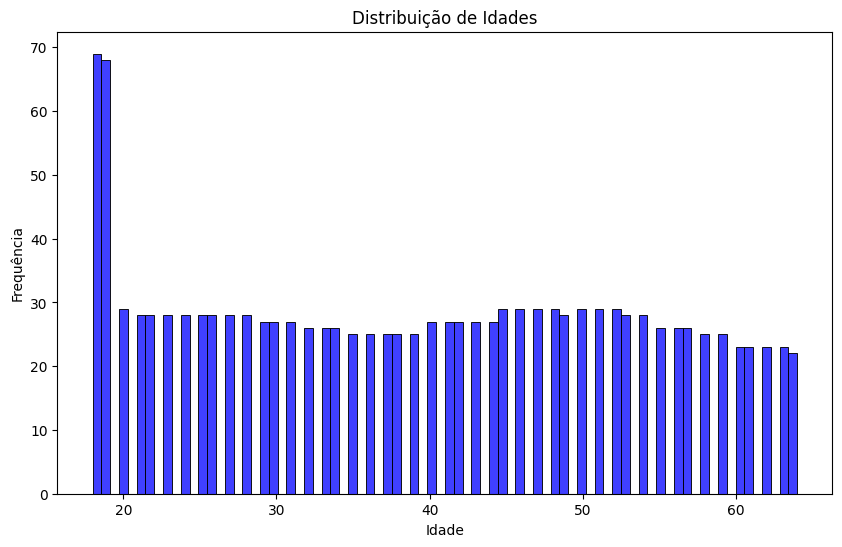

In [ ]:
# Histograma de idades
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=80)
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

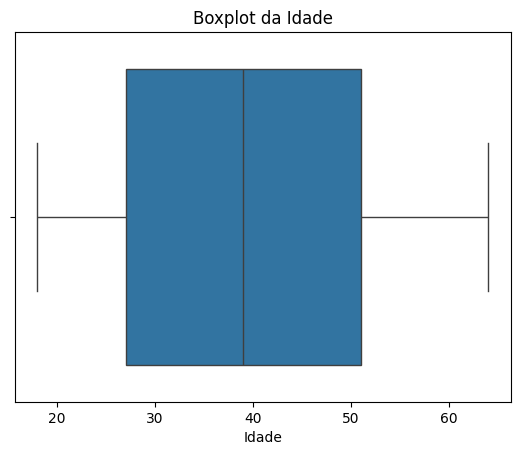

In [8]:
sns.boxplot(x=df['age'])
plt.title('Boxplot da Idade')
plt.xlabel('Idade')
plt.show()

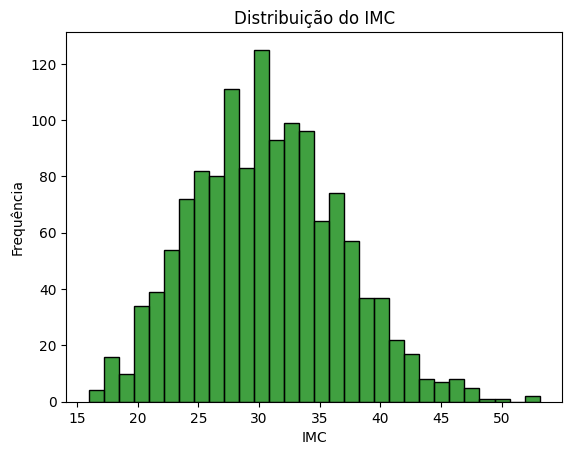

In [9]:
sns.histplot(df['bmi'], bins=30, color='green')
plt.title('Distribuição do IMC')
plt.xlabel('IMC')
plt.ylabel('Frequência')
plt.show()

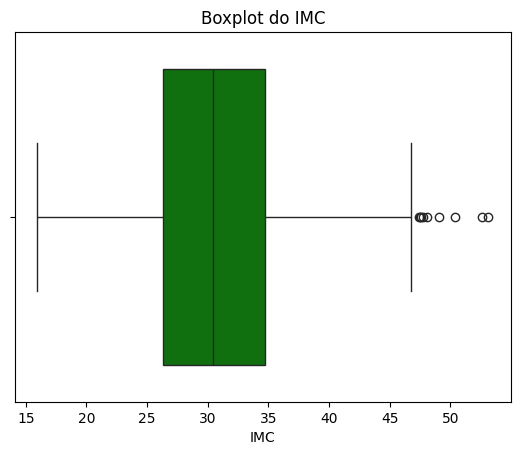

In [34]:
sns.boxplot(x=df['bmi'], color='green')
plt.title('Boxplot do IMC')
plt.xlabel('IMC')
plt.show()  

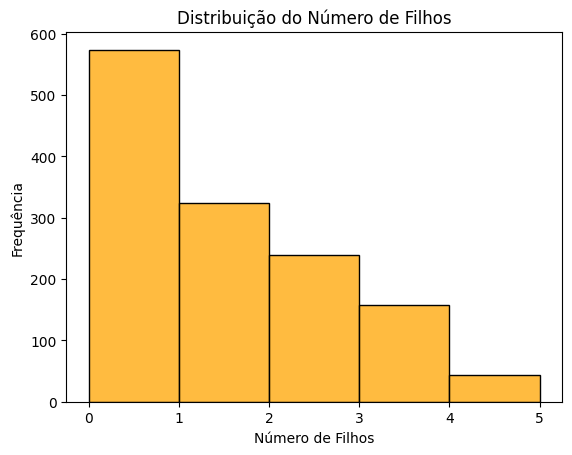

In [35]:
sns.histplot(df['children'], bins=5, color='orange')
plt.title('Distribuição do Número de Filhos')
plt.xlabel('Número de Filhos')
plt.ylabel('Frequência')
plt.show()

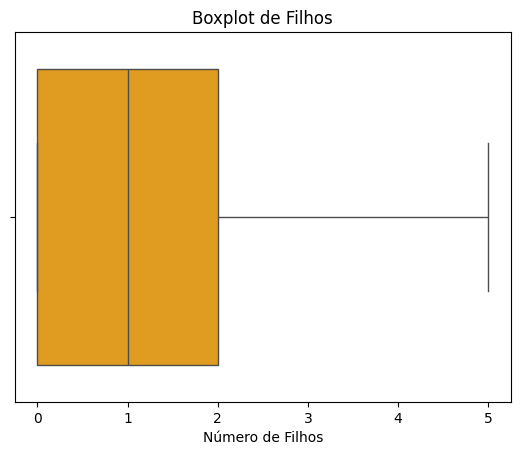

In [30]:
sns.boxplot(x=df['children'], color='orange')
plt.title('Boxplot de Filhos')
plt.xlabel('Número de Filhos')
plt.show()

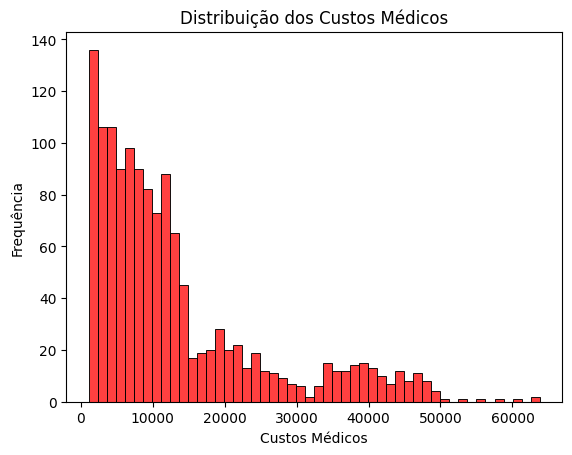

In [13]:
sns.histplot(df['charges'], bins=50, color='red')
plt.title('Distribuição dos Custos Médicos')
plt.xlabel('Custos Médicos')
plt.ylabel('Frequência')
plt.show()

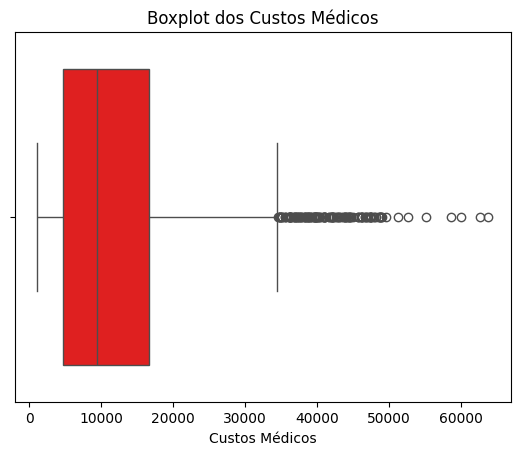

In [36]:
sns.boxplot(x=df['charges'], color='red')
plt.title('Boxplot dos Custos Médicos')
plt.xlabel('Custos Médicos')
plt.show()

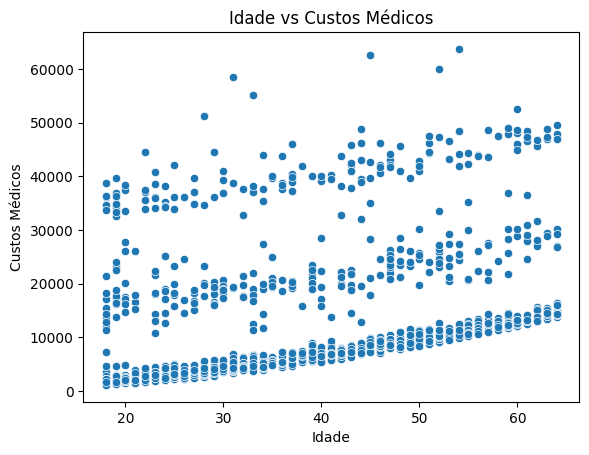

In [15]:
# Os custos médicos são influenciados pela idade?
sns.scatterplot(data=df, x='age', y='charges')
plt.title('Idade vs Custos Médicos')
plt.xlabel('Idade')
plt.ylabel('Custos Médicos')
plt.show()

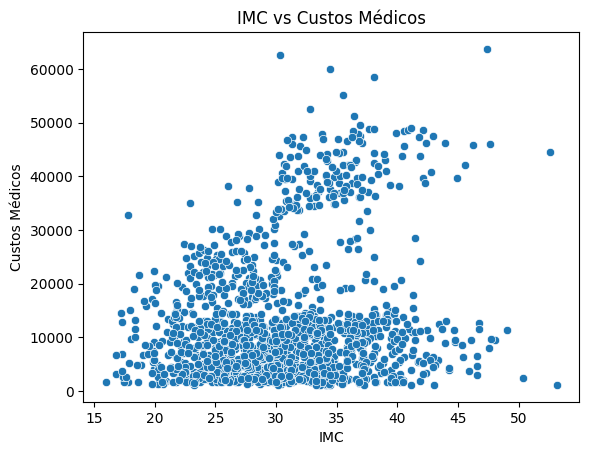

In [16]:
# Qual o impacto do IMC nos custos médicos?
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('IMC vs Custos Médicos')
plt.xlabel('IMC')
plt.ylabel('Custos Médicos')
plt.show()

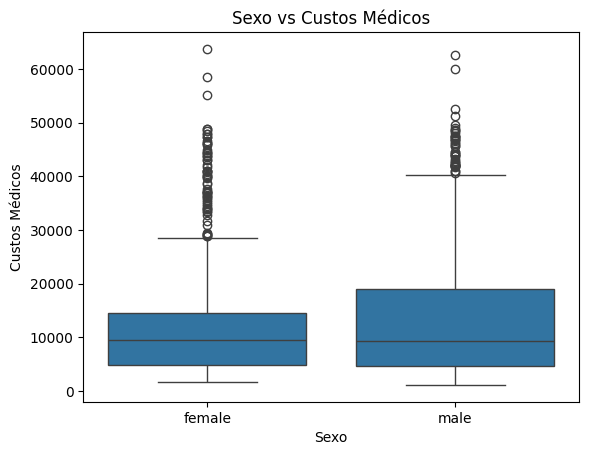

In [33]:
# Sexo e custos médicos
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Sexo vs Custos Médicos')
plt.xlabel('Sexo')
plt.ylabel('Custos Médicos')
plt.show()

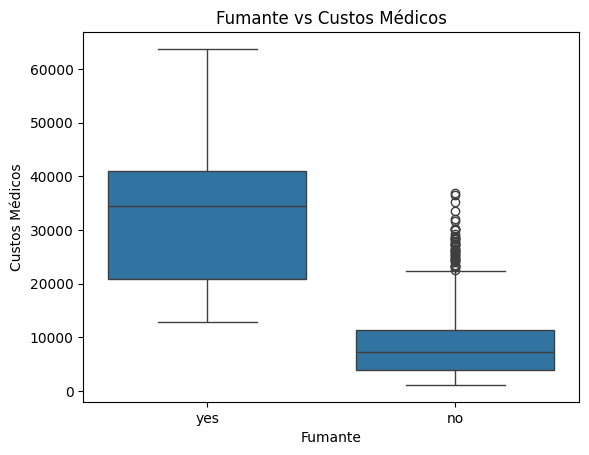

In [18]:
# Fumante e custos médicos
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Fumante vs Custos Médicos')
plt.xlabel('Fumante')
plt.ylabel('Custos Médicos')
plt.show()

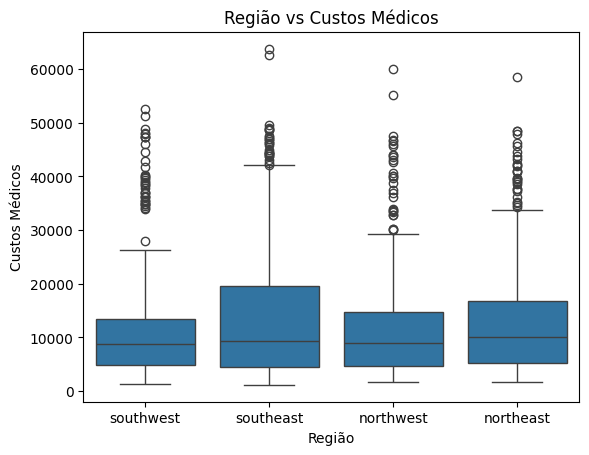

In [19]:
# Região e custos médicos
sns.boxplot(x='region', y='charges', data=df)
plt.title('Região vs Custos Médicos')
plt.xlabel('Região')
plt.ylabel('Custos Médicos')
plt.show()

### Correlação

In [38]:
# Transformando sexo em variável binário
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 0, 'female': 1})

# Transformando fumante em variável binário
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# Transformando região em variáveis dummy
df_encoded = pd.get_dummies(df_encoded, columns=['region'])    

# Visualizando o dataframe codificado
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


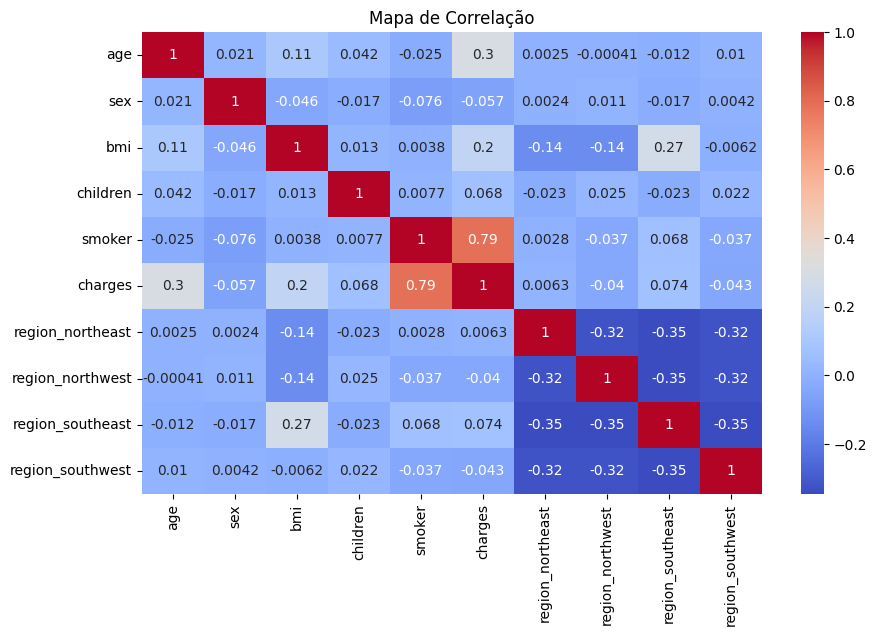

In [39]:
# Correlação entre as variáveis numéricas
plt.figure(figsize=(10,6))  
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()

In [40]:
# Separando features e target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
print(f'Tamanho do conjunto de treino: {X_train.shape[0]}')
print(f'Tamanho do conjunto de teste: {X_test.shape[0]}')

Tamanho do conjunto de treino: 1070
Tamanho do conjunto de teste: 268


In [24]:
# Padronizando e normalizando os dados

# Inicializar o scaler
scaler_X = StandardScaler() # Para as features
scaler_y = StandardScaler() # Para a variável target

# Colunas numéricas que precisam de padronização
numeric_cols = ['age', 'bmi', 'children'] 
# Obs: 'sex', 'smoker' e 'region' já são binárias/dummies e não precisam

# Padronizar as FEATURES (X)
X_train[numeric_cols] = scaler_X.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler_X.transform(X_test[numeric_cols])

# Padronizar a VARIÁVEL TARGET (Y)
# Deve ser feita a transformação para que os modelos treinem na mesma escala.
# É importante remodelar (reshape) para (n_samples, 1) antes de usar o scaler
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)) 

# O y_train/y_test agora são arrays NumPy na nova escala. 
# Para manter a consistência, remova o reshaping no final, se necessário.
y_train_scaled = y_train_scaled.flatten()
y_test_scaled = y_test_scaled.flatten()

## Usando o Modelo de Regressão Linear

In [25]:
model = LinearRegression()
model.fit(X_train, y_train_scaled)

# Fazendo previsões
y_pred = model.predict(X_test)

# Avaliando o modelo
mae = mean_absolute_error(y_test_scaled, y_pred)
mse = mean_squared_error(y_test_scaled, y_pred)
r2 = r2_score(y_test_scaled, y_pred)

## Usando o Modelo de Árvore de Decisão

In [26]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train_scaled)

# Fazendo previsões
y_pred_dt = model_dt.predict(X_test)

# Avaliando o modelo de árvore de decisão
mae_dt = mean_absolute_error(y_test_scaled, y_pred_dt)
mse_dt = mean_squared_error(y_test_scaled, y_pred_dt)  
r2_dt = r2_score(y_test_scaled, y_pred_dt)

## Usando o RandomForestRegressor

In [27]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train_scaled)

# Fazendo previsões
y_pred_rf = model_rf.predict(X_test)

# Avaliando o modelo Random Forest
mae_rf = mean_absolute_error(y_test_scaled, y_pred_rf)
mse_rf = mean_squared_error(y_test_scaled, y_pred_rf)
r2_rf = r2_score(y_test_scaled, y_pred_rf)


## Usando o modelo svm

In [28]:
model_svr = SVR(kernel='linear')
model_svr.fit(X_train, y_train_scaled)

# Fazendo previsões
y_pred_svr = model_svr.predict(X_test)

# Avaliando o modelo SVM
mae_svr = mean_absolute_error(y_test_scaled, y_pred_svr)
mse_svr = mean_squared_error(y_test_scaled, y_pred_svr)
r2_svr = r2_score(y_test_scaled, y_pred_svr)

In [29]:
# Tabela de Comparação entre os modelos
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'MAE': [mae, mae_dt, mae_rf, mae_svr],
    'MSE': [mse, mse_dt, mse_rf, mse_svr],
    'R^2 Score': [r2, r2_dt, r2_rf, r2_svr]
})

results

,Model,MAE,MSE,R^2 Score
0,Linear Regression,0.348030,0.232773,0.783593
1,Decision Tree,0.268365,0.302278,0.718974
2,Random Forest,0.209819,0.143107,0.866954
3,SVM,0.272983,0.275540,0.743832
